# Hands-on Practice: Image Processing with OpenCV

Today we will learn how computers represent and analyze images.

Although we can easily recognize people, animals, flowers, and X-rays, computers do not see objects directly. They only see arrays of numbers called pixels.

In this hands-on activity, we will explore how OpenCV can process these pixel values to extract useful information from images.

We will learn how to:

- Read and display images
- Understand image structure and pixel values
- Visualize color distributions using histograms
- Detect edges using Sobel and Canny operators
- Segment objects from the background using Watershed segmentation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries for image processing, numerical computing, and visualization
import cv2  # OpenCV library for image processing
import numpy as np  # NumPy is used for array and matrix operations

from google.colab.patches import cv2_imshow  # Display OpenCV images in Google Colab
import matplotlib.pyplot as plt  # Display images, plots, and histograms

In [3]:
# Read the image from Google Drive
# OpenCV loads the image as a NumPy array of pixel values
original_img = cv2.imread('/content/drive/My Drive/AISummerSchool2026/pitt.png')

## Understanding Image Shape

Let's first look at how an image is stored.

A grayscale image stores one value for each pixel.

A color image stores three values for each pixel.

When we print the image shape, we can see the image height, width, and number of color channels.

<class 'numpy.ndarray'>
(296, 302, 3)


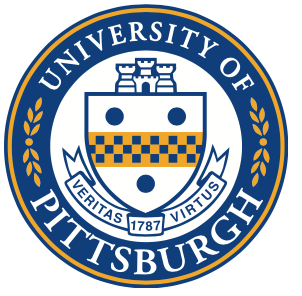

In [4]:
# Check image dimensions
# Shape format: height, width, number of color channels
original_img.shape

print(type(original_img))
print(original_img.shape)

# Display the image
cv2_imshow(original_img)

# Close the image display window
cv2.waitKey(0)
cv2.destroyAllWindows()

## Color Histograms

Now let's look inside the image.

Instead of looking at the picture itself, we will look at the distribution of pixel values.

Each histogram shows how frequently different intensity values appear in a color channel.

This helps us understand the brightness and color composition of the image.

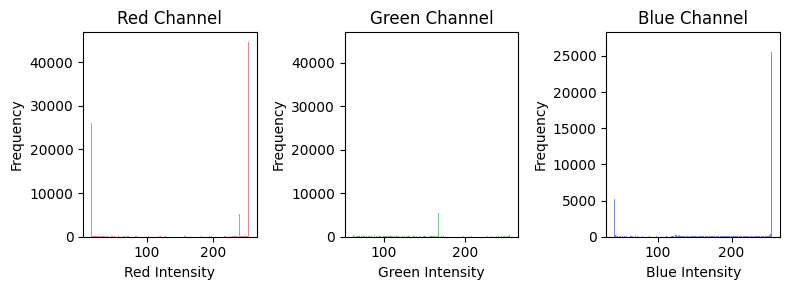

In [ ]:
# OpenCV reads color images in BGR order
# Convert the image from BGR to RGB for correct color display
image_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Split the RGB image into three separate color channels
r, g, b = cv2.split(image_rgb)

# Create a figure for showing the three histograms
plt.figure(figsize=(8, 3))

# Plot histogram for the red channel
plt.subplot(1, 3, 1)   # rows, columns, position
plt.hist(r.ravel(), color='r', bins=256, alpha=0.5)
plt.xlabel('Red Intensity')
plt.ylabel('Frequency')
plt.title('Red Channel')

# Plot histogram for the green channel
plt.subplot(1, 3, 2)
plt.hist(g.ravel(), color='g', bins=256, alpha=0.5)
plt.xlabel('Green Intensity')
plt.ylabel('Frequency')
plt.title('Green Channel')

# Plot histogram for the blue channel
plt.subplot(1, 3, 3)
plt.hist(b.ravel(), color='b', bins=256, alpha=0.5)
plt.xlabel('Blue Intensity')
plt.ylabel('Frequency')
plt.title('Blue Channel')

# Adjust spacing and display the plots
plt.tight_layout()
plt.show()

# Edge detection section

## What is an Edge?

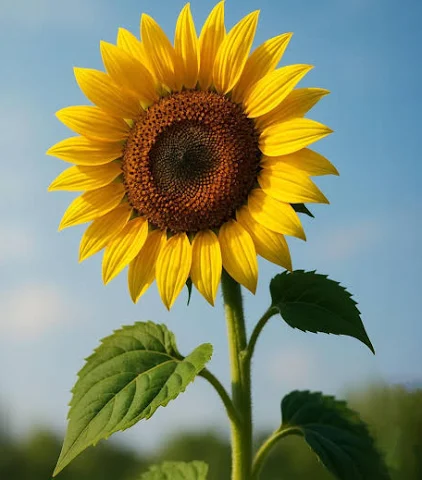


An edge occurs where image intensity changes rapidly.

In this image:

- The boundary between the flower and the sky forms an edge.
- The boundary between the leaves and the background forms an edge.
- The texture inside the flower center also contains many small edges.

Edge detection algorithms look for these rapid brightness changes and mark them as object boundaries.

## Canny Edge Detection

Objects are often separated by boundaries.

These boundaries usually appear where image intensity changes rapidly.

Canny detects these strong intensity changes and marks them as edges.

The threshold values control how sensitive the detector is.

The two thresholds control how strict the edge detector is.

- Edge strength < threshold1 → Ignore
- Edge strength > threshold2 → Strong Edge
- threshold1 ≤ Edge strength ≤ threshold2 → Maybe Edge

Maybe edges are kept only if they connect to a strong edge.

This helps remove noise while preserving important boundaries.

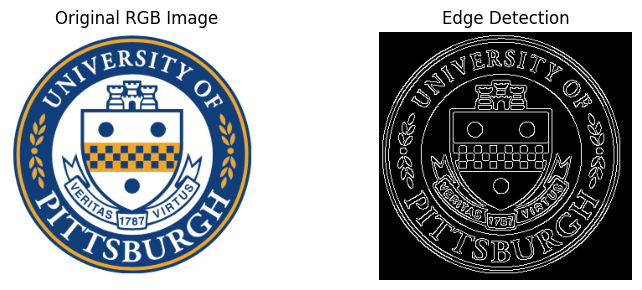

In [ ]:
# Edge detection using the Canny algorithm

# Convert the RGB image to grayscale
# Edge detection only needs intensity changes, not color information
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2GRAY)

# Apply Canny edge detection
# Lower thresholds detect more edges
# Higher thresholds detect only stronger edges
edges = cv2.Canny(gray_image, threshold1=10, threshold2=20)

# Which image contains more edges?
# cv2.Canny(gray_image,10,20)
# cv2.Canny(gray_image,50,100)
# cv2.Canny(gray_image,100,200)
# cv2.Canny(gray_image,200,300)


# Display the original image and the detected edges side by side
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

## Sobel Edge Detection

Another way to find edges is the Sobel operator.

Sobel measures intensity changes in the horizontal and vertical directions separately.

These intensity changes are called gradients.

A gradient describes how quickly brightness changes from one pixel to the next. For example, if neighboring pixels change from 10 to 250, the change is very large and produces a strong gradient.

Large gradients often occur at object boundaries, making them useful for edge detection.

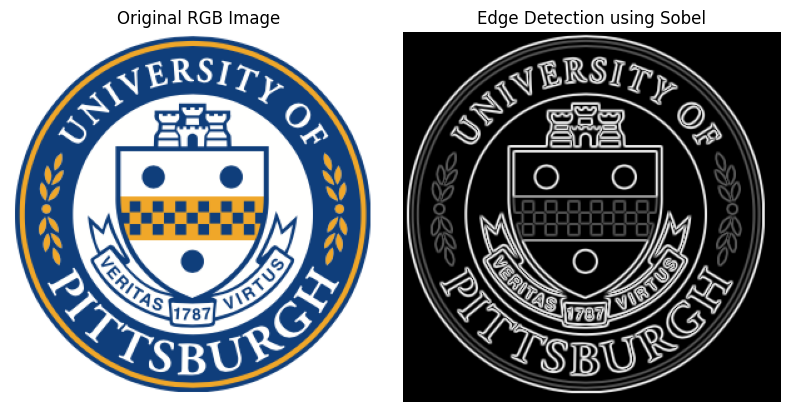

In [ ]:
# Edge detection using the Sobel algorithm
# For each pixel, Sobel looks at the 3×3 neighborhood centered around that pixel and
# computes how much the brightness changes within that neighborhood.

# Convert the RGB image to grayscale
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2GRAY)

# Compute horizontal gradient
# Compares neighboring pixels across a row. This detects changes from left to right
sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)

# Compute vertical gradient
# Compares neighboring pixels across a column. This detects changes from top to bottom
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)

# Combine horizontal and vertical gradients (Pythagorean theorem)
# This gives the overall edge strength
sobel_edges = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

# Display the original image and Sobel edge result
plt.figure(figsize=(8, 35))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_edges, cmap='gray')
plt.title('Edge Detection using Sobel')
plt.axis('off')

plt.tight_layout()
plt.show()

## Medical Imaging Example

The same edge detection methods can also be applied to medical images.

Here we use a knee X-ray image.

Notice how the bone boundaries become more visible after edge detection.

In [ ]:
# Load a knee X-ray image from Google Drive
knee_img = cv2.imread('/content/drive/My Drive/AISummerSchool2026/knee_lateral.jpeg')

# Get image dimensions
height, width, channels = knee_img.shape

# Print image size information
print("Width:", width)
print("Height:", height)
print("Number of channels:", channels)

Width: 451
Height: 630
Number of channels: 3


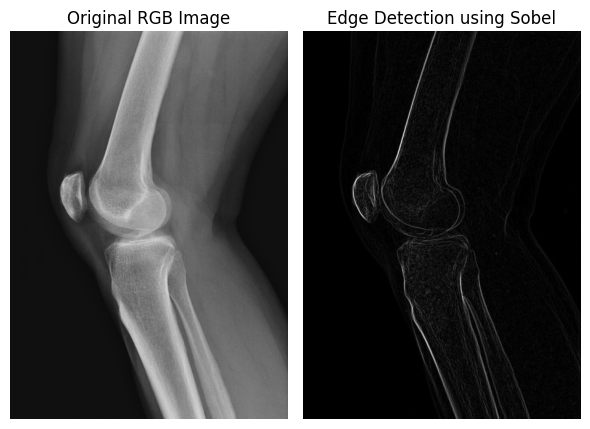

In [ ]:
# Apply Sobel edge detection to the knee X-ray image

# Convert the knee image to grayscale
gray_image = cv2.cvtColor(knee_img, cv2.COLOR_BGR2GRAY)

# Compute horizontal and vertical gradients
sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)

# Combine both gradient directions
sobel_edges = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

# Display the knee image and its edge map
plt.figure(figsize=(6, 25))

plt.subplot(1, 2, 1)
plt.imshow(knee_img)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_edges, cmap='gray')
plt.title('Edge Detection using Sobel')
plt.axis('off')

plt.tight_layout()
plt.show()

# Image segmentation section

## Thresholding

So far we have worked with grayscale images.

Now we will convert the image into a binary image.

After thresholding, every pixel becomes either black or white.

This makes it easier to separate objects from the background.

In [ ]:
# Load a sample image for segmentation
img = cv2.imread('/content/drive/My Drive/AISummerSchool2026/sample.jpg')

# Convert image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Otsu thresholding
# This automatically selects a threshold value (ret)
# The result is a binary image: object and background (thresh)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

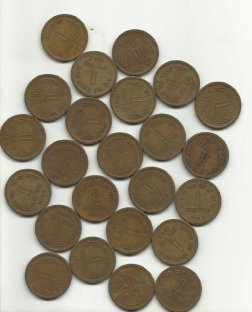

In [ ]:
# Display the original image used for segmentation
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()

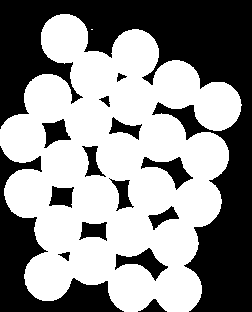

In [ ]:
# Display the binary threshold result
# White regions represent objects
# Black regions represent background
cv2_imshow(thresh)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Watershed Segmentation

Thresholding can separate objects from the background, but it often struggles when objects touch each other.

To address this problem, we use the Watershed algorithm.

The main idea is to first identify the center of each object and then gradually expand outward. As neighboring regions grow, they eventually meet, and the meeting points become object boundaries.

The workflow is:

1. Remove small noise from the binary image.
2. Identify regions that are definitely background.
3. Identify regions that are definitely part of an object, usually near the object center.
4. Mark the uncertain regions between the foreground and background.
5. Grow regions outward from the object centers.
6. Create boundaries when neighboring regions meet.

The final boundaries are displayed in red.


In [ ]:
# Create a small kernel for morphological operations, For a k × k kernel, each dilation operation expands the object boundary by approximately (k − 1) / 2 pixels in every direction.
kernel = np.ones((3,3), np.uint8)

# Remove small noise from the binary image
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Find the sure background by expanding object regions (Expanded Region/ Background Candidate)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Compute distance from each object pixel to the nearest background pixel
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Identify the sure foreground, which is the center area of each object
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Convert foreground result to integer format
sure_fg = np.uint8(sure_fg)

# Find unknown regions between foreground and background
unknown = cv2.subtract(sure_bg, sure_fg)

# Label each connected foreground object
ret, markers = cv2.connectedComponents(sure_fg)

# Add 1 so the background is not labeled as 0
markers = markers + 1

# Mark unknown regions as 0 for watershed
markers[unknown == 255] = 0

# Apply watershed segmentation
markers = cv2.watershed(img, markers)

# Mark watershed boundaries in red
img[markers == -1] = [0, 0, 255]

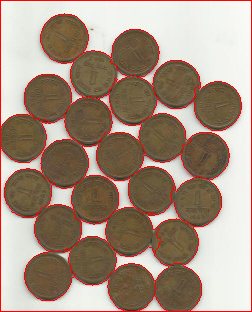

In [ ]:
# Display the final segmented image
# Red lines show the detected object boundaries
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Summary

Today we learned that images are simply arrays of numbers.

We explored how to:

- Visualize pixel values using histograms
- Detect edges using Canny and Sobel operators
- Convert images into binary images
- Segment objects using watershed segmentation

These are fundamental techniques used in computer vision and medical image analysis.